In [1]:
import scanpy as sc
import pandas as pd
import liana as li

In [39]:
adata = sc.read_h5ad("adata_xeno_with_symbols.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 75467 × 41560
    obs: 'barcode_base', 'CellBarcode', 'Stages', 'CellType', 'Phenograph', 'Pseudotime_Pltr', 'Differentiation Potential_Pltr', 'Per Stage Louvain', 'CytoTRACE', 'CV', 'CCphase', 'Branch Probabilities Basal', 'Branch Probabilities Goblet', 'Branch Probabilities Ionocytes', 'Branch Probabilities Multiciliated', 'stage_from_file', 'sample', 'in_meta'
    var: 'raw_name', 'xeno_symbol', 'ORTHOLOG_HUMAN_SYMBOL'


In [32]:
adata = sc.read_h5ad("adata_xeno_with_symbols.h5ad")
adata = adata[adata.obs["Phenograph"].notna()].copy()
adata = adata[:, adata.var["ORTHOLOG_HUMAN_SYMBOL"].notna()].copy()
adata.var_names = adata.var["ORTHOLOG_HUMAN_SYMBOL"].astype(str)
adata.var_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 33985 × 16028
    obs: 'barcode_base', 'CellBarcode', 'Stages', 'CellType', 'Phenograph', 'Pseudotime_Pltr', 'Differentiation Potential_Pltr', 'Per Stage Louvain', 'CytoTRACE', 'CV', 'CCphase', 'Branch Probabilities Basal', 'Branch Probabilities Goblet', 'Branch Probabilities Ionocytes', 'Branch Probabilities Multiciliated', 'stage_from_file', 'sample', 'in_meta'
    var: 'raw_name', 'xeno_symbol', 'ORTHOLOG_HUMAN_SYMBOL'


In [22]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

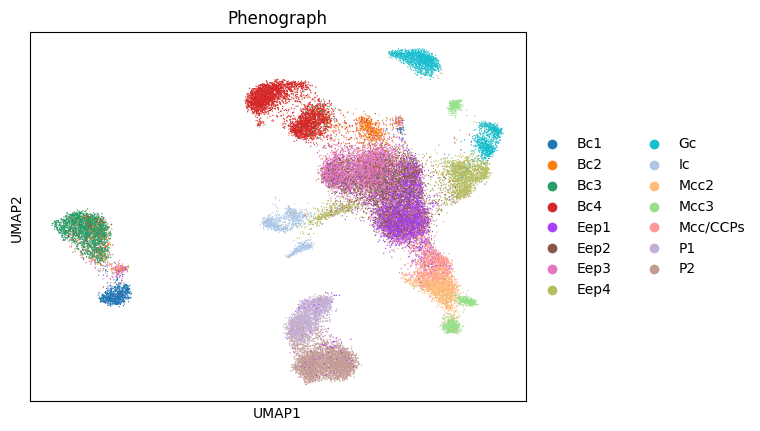

In [23]:
sc.pl.umap(adata, color="Phenograph")

In [33]:
# import all individual methods
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

In [34]:
adata_st22 = adata[adata.obs["Stages"] == "st22"].copy()

In [26]:
adata_st22.var_names

Index(['SUCLG1', 'ADRA1D', 'SMOX', 'RNF24', 'GNRH2', 'AVP', 'UBOX5', 'LZTS3',
       'ATRN', 'SLC4A11',
       ...
       'CLDN6-2', 'SRRM2-1', 'PHGDH-1', 'RRAGA-1', 'GBP7', 'GBP4', 'PPIL3',
       'NIF3L1', 'RNF112', 'MFAP4'],
      dtype='object', name='ORTHOLOG_HUMAN_SYMBOL', length=16028)

In [6]:
li.mt.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


In [ ]:
cellphonedb(
            adata_st22,
            groupby='Phenograph',
            resource_name='consensus',
            expr_prop=0.1,
            verbose=True,
            key_added='cpdb_res',
            use_raw=False
        )

Using resource `consensus`.
Using `.X`!
c:\Users\ljd567\AppData\Local\miniconda3\envs\stgpu\lib\site-packages\anndata\_core\anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
2099 features of mat are empty, they will be removed.
c:\Users\ljd567\AppData\Local\miniconda3\envs\stgpu\lib\site-packages\liana\method\_pipe_utils\_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
c:\Users\ljd567\AppData\Local\miniconda3\envs\stgpu\lib\site-packages\liana\method\_pipe_utils\_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.62 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 5217 samples and 560 features


100%|██████████| 1000/1000 [00:04<00:00, 207.60it/s]


In [67]:
li.mt.rank_aggregate(adata_st22, 
                     groupby='Phenograph',
                     resource_name='consensus',
                     expr_prop=0.01,
                     verbose=True,
                     use_raw=False)

Using resource `consensus`.
Using `.X`!
c:\Users\ljd567\AppData\Local\miniconda3\envs\stgpu\lib\site-packages\anndata\_core\anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
2099 features of mat are empty, they will be removed.
Make sure that normalized counts are passed!
c:\Users\ljd567\AppData\Local\miniconda3\envs\stgpu\lib\site-packages\liana\method\_pipe_utils\_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
c:\Users\ljd567\AppData\Local\miniconda3\envs\stgpu\lib\site-packages\liana\method\_pipe_utils\_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
The following cell identities were excluded: Mcc/CCPs
0.62 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 5216 samples and 560 features
Assuming that counts were `natural` log-normalized!


c:\Users\ljd567\AppData\Local\miniconda3\envs\stgpu\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
c:\Users\ljd567\AppData\Local\miniconda3\envs\stgpu\lib\site-packages\liana\method\sc\_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.


Running CellPhoneDB


100%|██████████| 1000/1000 [00:08<00:00, 121.09it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [68]:
print(adata_st22.uns.keys())


odict_keys(['CellType_colors', 'liana_res'])


In [69]:
adata_st22.uns["liana_res"]

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
1727,Bc3,Bc1,MDK,NCL,4.906938,0.000,5.277287,0.760223,8.171664,0.057787,0.974480,0.001227,2.102056e-07
83,Bc1,Bc1,MDK,NCL,4.807750,0.000,3.443714,0.612568,7.464697,0.037709,0.968598,0.006164,8.407369e-07
2689,Bc4,Bc1,MDK,NCL,4.753814,0.000,2.446656,0.532277,7.342330,0.026791,0.962962,0.009116,7.563548e-06
894,Bc2,Bc1,MDK,NCL,4.750772,0.000,2.390412,0.527748,7.419723,0.026175,0.962545,0.009116,1.029378e-05
2048,Bc3,Bc3,MDK,NCL,3.113416,0.000,3.229248,0.277780,-5.287639,0.035361,0.967606,0.153473,3.023569e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,Bc1,Bc1,BMP4,ACVR2A_BMPR1A,0.066319,1.000,0.003993,-0.050578,-0.143663,0.018681,0.512288,1.000000,1.000000e+00
6540,Mcc3,Mcc3,SEMA4G,PLXNB2,0.023416,0.997,0.000531,-0.082257,-0.042120,0.008932,0.276990,1.000000,1.000000e+00
6533,Mcc3,Mcc3,MDK,SDC4,0.038567,1.000,0.000873,-0.232917,-0.440510,0.002015,0.329329,1.000000,1.000000e+00
6538,Mcc3,Mcc3,SEMA4A,PLXNB2,0.022039,1.000,0.000455,-0.187088,-0.149083,0.003034,0.261823,1.000000,1.000000e+00


In [58]:
res = adata_st22.uns["liana_res"]
print(res.columns)


Index(['source', 'target', 'ligand_complex', 'receptor_complex', 'lr_means',
       'cellphone_pvals', 'expr_prod', 'scaled_weight', 'lr_logfc',
       'spec_weight', 'lrscore', 'specificity_rank', 'magnitude_rank'],
      dtype='object')


In [78]:
paper_xeno = [
    "notch3.L", "notch1.S", "hes5.1.L", "hes9.1.S", "hes5.1.S",
    "hes5.2.S", "hes4.L", "dlc.L", "dll1.L", "notch2.L", "jag2.L", "dll4.L"
]

check = (
    adata.var[["xeno_symbol", "ORTHOLOG_HUMAN_SYMBOL"]]
    .drop_duplicates()
)

check[check["xeno_symbol"].isin(paper_xeno)].sort_values("xeno_symbol")


,xeno_symbol,ORTHOLOG_HUMAN_SYMBOL
gene17405|dlc.L,dlc.L,NaN
gene41082|dll1.L,dll1.L,DLL1
gene20374|dll4.L,dll4.L,DLL4
gene19742|hes4.L,hes4.L,HES4
gene18133|hes5.1.L,hes5.1.L,NaN
gene37268|hes5.1.S,hes5.1.S,NaN
gene34361|hes5.2.S,hes5.2.S,HES5
gene45923|hes9.1.S,hes9.1.S,NaN
gene442|jag2.L,jag2.L,JAG2
gene49280|notch1.S,notch1.S,NOTCH1


In [79]:
resource = li.rs.select_resource("consensus")
lr_genes = set(resource["ligand"]).union(set(resource["receptor"]))

paper_human = set(
    check[check["xeno_symbol"].isin(paper_xeno)]["ORTHOLOG_HUMAN_SYMBOL"]
)

print("In data:", sorted(set(paper_human) & set(adata_st22.var_names)))
print("In LR resource:", sorted(set(paper_human) & lr_genes))
print("In both:", sorted(set(paper_human) & set(adata_st22.var_names) & lr_genes))


In data: ['DLL1', 'DLL4', 'HES4', 'HES5', 'JAG2', 'NOTCH1', 'NOTCH2', 'NOTCH3']
In LR resource: ['DLL1', 'DLL4', 'JAG2', 'NOTCH1', 'NOTCH2', 'NOTCH3']
In both: ['DLL1', 'DLL4', 'JAG2', 'NOTCH1', 'NOTCH2', 'NOTCH3']


In [15]:
gene =  ['ANGPT4', 'ANXA2', 'NOTCH2']
res_gen = set(res['ligand_complex']).union(set(res['receptor_complex']))


In [16]:
print(res_gen.intersection(gene))

{'NOTCH2'}


In [74]:
genes_to_check = ["YBX1", "NOTCH1",'MDK',"NOTCH2","ADAM17"]
genes_present = [g for g in genes_to_check if g in adata_st22.var_names]
print("Present in adata_st22:", genes_present)

Present in adata_st22: ['YBX1', 'NOTCH1', 'MDK', 'NOTCH2', 'ADAM17']


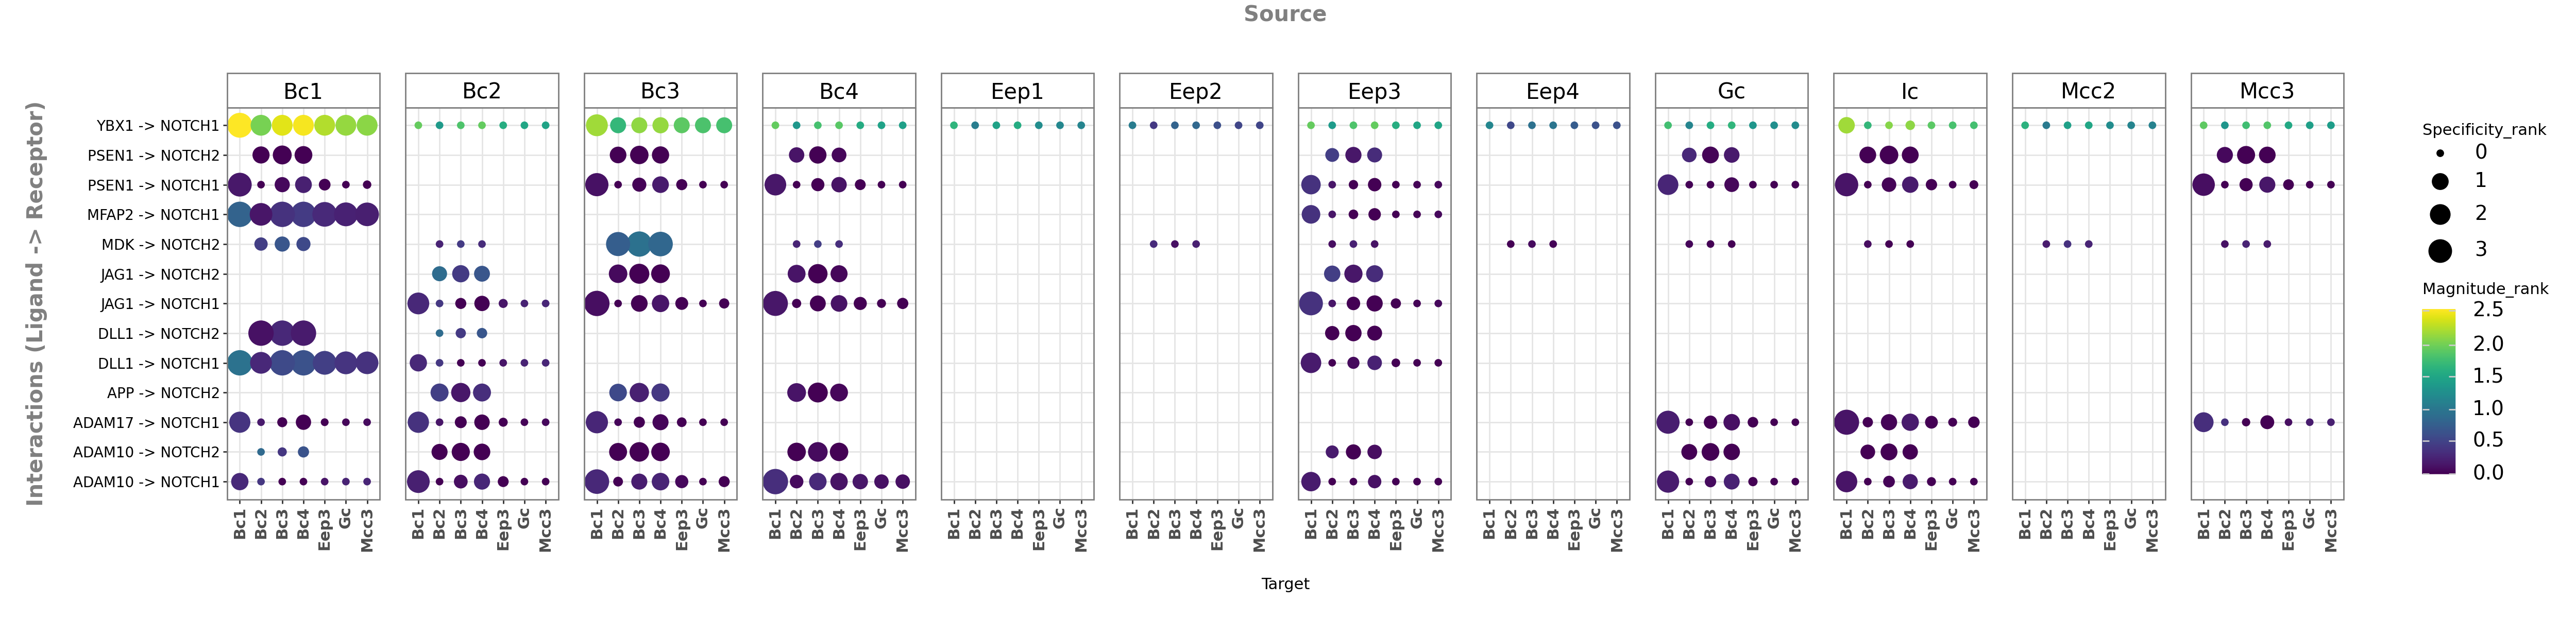

In [ ]:
li.pl.dotplot(
    adata=adata_st22,
    uns_key="liana_res",
    receptor_complex=["NOTCH2","NOTCH1"],
    colour="magnitude_rank",
    size="specificity_rank",
    inverse_colour=True,
    inverse_size=True,
    figure_size=(25, 6)
)
